# What Actually Drives a Used Car’s Price? I Cleaned 4,009 Listings to Find Out

**Short answer: age drives the price, brand sets the level, and clean data makes the difference.**

**Dataset:** Used Car Price Prediction (Kaggle) | **Tools:** Python, Pandas, NumPy, Matplotlib, Seaborn

## The Question

What really drives a used car’s price: **age, brand tier, or miles driven per year?**


## Step 1 : Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_columns", None)
os.makedirs("../charts", exist_ok=True)

## Step 2 : Loading the Data

In [2]:
df = pd.read_csv("D:\\weekly-data-science-challenges\\week06-used-cars\\data\\raw\\used_cars.csv")
print(df.shape)
df.head()

(4009, 12)


,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,Ford,Utility Police Interceptor Base,2013,"51,000 mi.",E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,"$10,300"
1,Hyundai,Palisade SEL,2021,"34,742 mi.",Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,"$38,005"
2,Lexus,RX 350 RX 350,2022,"22,372 mi.",Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,NaN,"$54,598"
3,INFINITI,Q50 Hybrid Sport,2015,"88,900 mi.",Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,"$15,500"
4,Audi,Q3 45 S line Premium Plus,2021,"9,835 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,NaN,"$34,999"


## Step 3 : Inspecting Before Cleaning

In [3]:
print(df.dtypes)
print()
print(df.isna().sum())

brand             str
model             str
model_year      int64
milage            str
fuel_type         str
engine            str
transmission      str
ext_col           str
int_col           str
accident          str
clean_title       str
price             str
dtype: object

brand             0
model             0
model_year        0
milage            0
fuel_type       170
engine            0
transmission      0
ext_col           0
int_col           0
accident        113
clean_title     596
price             0
dtype: int64


In [4]:
print(df["fuel_type"].value_counts(dropna=False))
print()
print(df["accident"].value_counts(dropna=False))
print()
print(df["clean_title"].value_counts(dropna=False))

fuel_type
Gasoline          3309
Hybrid             194
NaN                170
E85 Flex Fuel      139
Diesel             116
–                   45
Plug-In Hybrid      34
not supported        2
Name: count, dtype: int64

accident
None reported                             2910
At least 1 accident or damage reported     986
NaN                                        113
Name: count, dtype: int64

clean_title
Yes    3413
NaN     596
Name: count, dtype: int64


In [5]:
# Brands that look truncated: a very short name, and the model starts with the missing word
print(df.loc[df["brand"].isin(["Land", "Aston", "Alfa"]), ["brand", "model"]].head(6))
print()
print(df["brand"].isin(["Land", "Aston", "Alfa"]).sum(), "affected rows")

     brand                                         model
10    Land  Rover Range Rover Sport 3.0 Supercharged HST
11   Aston                       Martin DBS Superleggera
15    Land                                 Rover LR4 HSE
80    Land            Rover Discovery Sport SE R-Dynamic
93   Aston                       Martin DBS Superleggera
110   Land            Rover LR4 HSE LUX Landmark Edition

158 affected rows


## Step 4 : Cleaning

### 4.1 Turning price and milage into real numbers

In [6]:
df["price"] = (df["price"].str.replace("$", "", regex=False)
                          .str.replace(",", "", regex=False).astype(float))
df["milage"] = (df["milage"].str.replace(" mi.", "", regex=False)
                            .str.replace(",", "", regex=False).astype(float))
df[["price", "milage"]].describe()

,price,milage
count,4.009000e+03,4009.000000
mean,4.455319e+04,64717.551010
std,7.871064e+04,52296.599459
min,2.000000e+03,100.000000
25%,1.720000e+04,23044.000000
50%,3.100000e+04,52775.000000
75%,4.999000e+04,94100.000000
max,2.954083e+06,405000.000000


### 4.2 Fixing the broken brand names

In [7]:
tails = {"Land": "Rover ", "Aston": "Martin ", "Alfa": "Romeo "}
full_names = {"Land": "Land Rover", "Aston": "Aston Martin", "Alfa": "Alfa Romeo"}

for short, tail in tails.items():
    mask = df["brand"] == short
    df.loc[mask, "model"] = df.loc[mask, "model"].str.replace(tail, "", n=1, regex=False)
    df.loc[mask, "brand"] = full_names[short]

print(df.loc[df["brand"].isin(full_names.values()), ["brand", "model"]].drop_duplicates("brand"))

            brand                                   model
10     Land Rover  Range Rover Sport 3.0 Supercharged HST
11   Aston Martin                        DBS Superleggera
151    Alfa Romeo                        Stelvio Ti Sport


### 4.3 Handle missing values with judgment

In [8]:
# fuel_type: who is missing?
bad_fuel = df["fuel_type"].isna() | df["fuel_type"].isin(["–", "not supported"])
print(df.loc[bad_fuel, "brand"].value_counts().head(5))
print()
print("Missing fuel rows whose engine says Electric:",
      df.loc[bad_fuel, "engine"].str.contains("Electric", case=False).sum(), "of", bad_fuel.sum())

brand
Tesla        87
Rivian       17
Ford         17
Porsche      11
Chevrolet     8
Name: count, dtype: int64

Missing fuel rows whose engine says Electric: 167 of 217


In [ ]:
# Recovering Electric from the engine text, everything else becomes Unknown
is_electric = df["engine"].str.contains("Electric Motor", case=False, na=False)
df.loc[bad_fuel & is_electric, "fuel_type"] = "Electric"
df.loc[df["fuel_type"].isna() | df["fuel_type"].isin(["–", "not supported"]), "fuel_type"] = "Unknown"
print(df["fuel_type"].value_counts())

fuel_type
Gasoline          3309
Hybrid             194
Electric           149
E85 Flex Fuel      139
Diesel             116
Unknown             68
Plug-In Hybrid      34
Name: count, dtype: int64


In [10]:
check = df.assign(title=df["clean_title"].fillna("Blank")).groupby("title").agg(
    listings=("price", "size"),
    median_price=("price", "median"),
    median_mileage=("milage", "median"),
    median_year=("model_year", "median"),
    accident_rate=("accident", lambda s: (s == "At least 1 accident or damage reported").mean()),
)
check.round(2)

,listings,median_price,median_mileage,median_year,accident_rate
title,,,,,
Blank,596,42996.5,23713.0,2020.5,0.07
Yes,3413,29000.0,60260.0,2016.0,0.28


In [11]:
df["clean_title"] = df["clean_title"].fillna("Not listed")
df["accident"] = df["accident"].fillna("Unknown")   # 113 rows: we cannot claim 'none reported'
print(df["clean_title"].value_counts())
print()
print(df["accident"].value_counts())
print()
print("Remaining nulls:", int(df.isna().sum().sum()))

clean_title
Yes           3413
Not listed     596
Name: count, dtype: int64

accident
None reported                             2910
At least 1 accident or damage reported     986
Unknown                                    113
Name: count, dtype: int64

Remaining nulls: 0


### 4.4 Check for price errors before building on price

In [12]:
df.sort_values("price", ascending=False)[["brand", "model", "model_year", "milage", "price"]].head(6)

,brand,model,model_year,milage,price
693,Maserati,Quattroporte Base,2005,32000.0,2954083.0
229,Bugatti,Veyron 16.4 Grand Sport,2011,6330.0,1950995.0
3046,Porsche,Carrera GT Base,2005,4400.0,1599000.0
1356,Lamborghini,Aventador SVJ Base,2021,6987.0,749950.0
624,Rolls-Royce,Cullinan,2022,398.0,695000.0
979,Lamborghini,Aventador SVJ Base,2019,6929.0,649999.0


In [13]:
df["price_suspect"] = (df["brand"] == "Maserati") & (df["model_year"] == 2005) & (df["price"] > 2_000_000)
print("Flagged rows:", df["price_suspect"].sum())
df_clean = df[~df["price_suspect"]].copy()
print(df_clean.shape)

Flagged rows: 1
(4008, 13)


## Step 5 : Feature Engineering (built only on the cleaned columns)

In [14]:
# Reference year 2025 (the dataset's newest model year is 2024)
df_clean["car_age"] = (2025 - df_clean["model_year"]).replace(0, 1)
df_clean["mileage_per_year"] = (df_clean["milage"] / df_clean["car_age"]).round(0)

luxury_brands = ["BMW", "Mercedes-Benz", "Audi", "Lexus", "Porsche", "Jaguar", "Land Rover",
                 "Bentley", "Maserati", "Ferrari", "Lamborghini", "Aston Martin", "Rolls-Royce",
                 "McLaren", "Maybach", "Bugatti", "Lotus", "Alfa Romeo", "Genesis"]
df_clean["brand_tier"] = np.where(df_clean["brand"].isin(luxury_brands), "Luxury", "Economy")

df_clean[["brand", "model_year", "car_age", "milage", "mileage_per_year", "brand_tier", "price"]].head()

,brand,model_year,car_age,milage,mileage_per_year,brand_tier,price
0,Ford,2013,12,51000.0,4250.0,Economy,10300.0
1,Hyundai,2021,4,34742.0,8686.0,Economy,38005.0
2,Lexus,2022,3,22372.0,7457.0,Luxury,54598.0
3,INFINITI,2015,10,88900.0,8890.0,Economy,15500.0
4,Audi,2021,4,9835.0,2459.0,Luxury,34999.0


In [15]:
print(df_clean["brand_tier"].value_counts())
print()
print(df_clean["mileage_per_year"].describe().round(0))

brand_tier
Economy    2402
Luxury     1606
Name: count, dtype: int64

count     4008.0
mean      6839.0
std       4270.0
min         33.0
25%       3750.0
50%       6336.0
75%       9227.0
max      44333.0
Name: mileage_per_year, dtype: float64


## Step 6 : Analysis

### Price by brand tier

In [16]:
tier_stats = df_clean.groupby("brand_tier")["price"].agg(["count", "mean", "median"]).round(0)
tier_stats

,count,mean,median
brand_tier,,,
Economy,2402,31795.0,27000.0
Luxury,1606,61823.0,39998.0


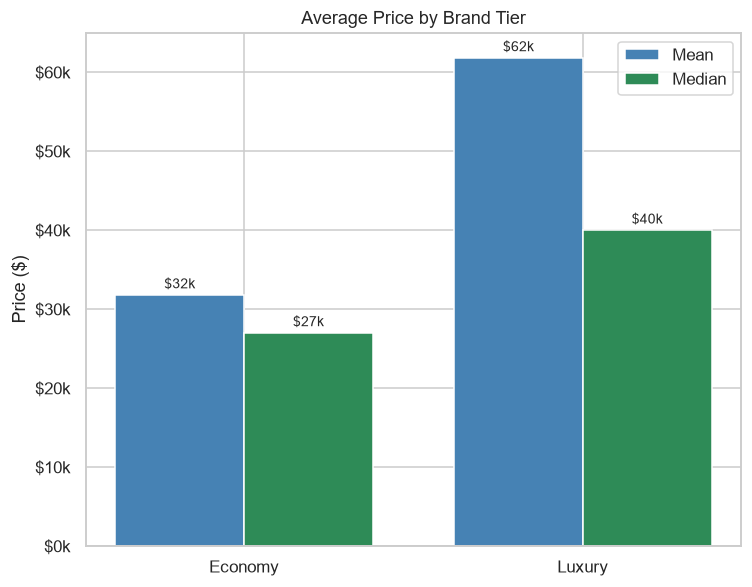

In [27]:
fig, ax = plt.subplots(figsize=(7, 5.5))
x = np.arange(len(tier_stats))
w = 0.38
ax.bar(x - w/2, tier_stats["mean"], w, label="Mean", color="steelblue")
ax.bar(x + w/2, tier_stats["median"], w, label="Median", color="seagreen")
ax.set_xticks(x); ax.set_xticklabels(tier_stats.index)
ax.set_title("Average Price by Brand Tier")
ax.set_ylabel("Price ($)")
ax.yaxis.set_major_formatter(lambda v, _: f"${v/1000:.0f}k")
for i, (m, med) in enumerate(zip(tier_stats["mean"], tier_stats["median"])):
    ax.text(i - w/2, m + 800, f"${m/1000:.0f}k", ha="center", fontsize=9)
    ax.text(i + w/2, med + 800, f"${med/1000:.0f}k", ha="center", fontsize=9)
ax.legend()
plt.tight_layout()
plt.savefig("../reports\\figures\\price_by_brand_tier.png")
plt.show()

### Price by car age

In [18]:
df_clean["age_band"] = pd.cut(df_clean["car_age"], [0, 3, 6, 10, 15, 60],
                              labels=["1-3 yrs", "4-6 yrs", "7-10 yrs", "11-15 yrs", "16+ yrs"])
age_tier = df_clean.pivot_table(index="age_band", columns="brand_tier", values="price",
                                aggfunc="median", observed=True).round(0)
age_tier["Luxury premium (x)"] = (age_tier["Luxury"] / age_tier["Economy"]).round(2)
age_tier

brand_tier,Economy,Luxury,Luxury premium (x)
age_band,,,
1-3 yrs,48995.0,80000.0,1.63
4-6 yrs,38468.0,55998.0,1.46
7-10 yrs,25264.0,35000.0,1.39
11-15 yrs,14000.0,20945.0,1.50
16+ yrs,10500.0,16000.0,1.52


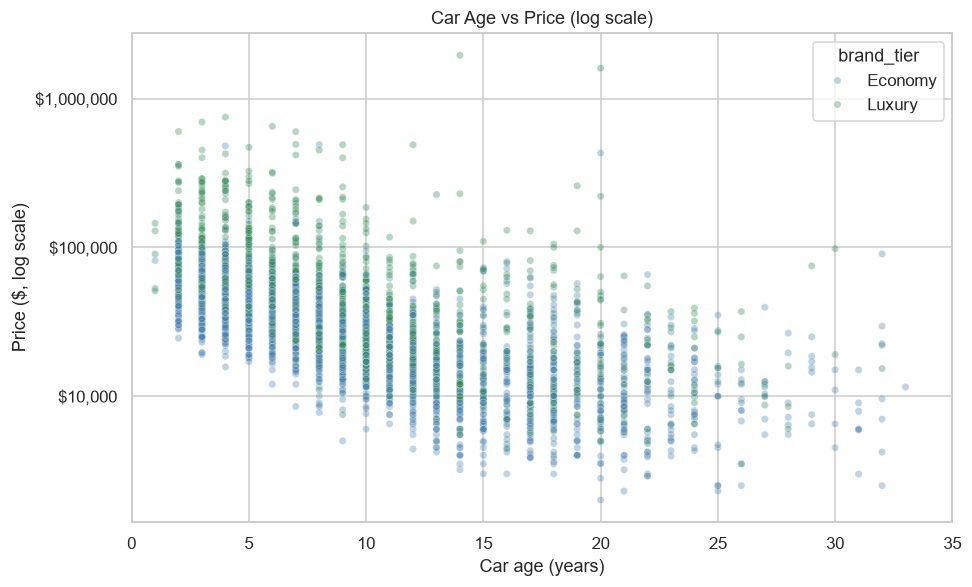

In [28]:
fig, ax = plt.subplots(figsize=(9, 5.5))
sns.scatterplot(data=df_clean, x="car_age", y="price", hue="brand_tier",
                alpha=0.35, s=22, ax=ax, palette={"Economy": "steelblue", "Luxury": "seagreen"})
ax.set_yscale("log")
ax.set_xlim(0, 35)   # one 1974 car (age 51) is cropped so the rest stays readable
ax.set_title("Car Age vs Price (log scale)")
ax.set_xlabel("Car age (years)")
ax.set_ylabel("Price ($, log scale)")
ax.yaxis.set_major_formatter(lambda v, _: f"${v:,.0f}")
plt.tight_layout()
plt.savefig("../reports\\figures\\age_vs_price.png")
plt.show()

### Which engineered feature predicts price best?

In [20]:
corr = (df_clean[["price", "car_age", "mileage_per_year", "milage"]]
        .corr(method="spearman")["price"].drop("price").round(2))
corr.sort_values()

milage             -0.76
car_age            -0.70
mileage_per_year   -0.40
Name: price, dtype: float64

'Car_age'  is the strongest engineered predictor, and raw mileage overlaps with age.

### Is there a mileage-per-year threshold?

In [21]:
df_clean["mpy_band"] = pd.cut(df_clean["mileage_per_year"], [-1, 3000, 6000, 9000, 12000, 15000, 1e7],
                              labels=["<3k", "3-6k", "6-9k", "9-12k", "12-15k", "15k+"])
mpy_stats = df_clean.groupby("mpy_band", observed=True)["price"].agg(["count", "median"]).round(0)
mpy_stats

,count,median
mpy_band,,
<3k,753,59000.0
3-6k,1135,33885.0
6-9k,1057,26500.0
9-12k,631,23000.0
12-15k,265,22500.0
15k+,167,26772.0


 Yes. Price drops fastest from under 3k to 3-6k miles per year, and flattens past about 9k. The 15k+ group rises again because work trucks and vans hold their value for a different reason.



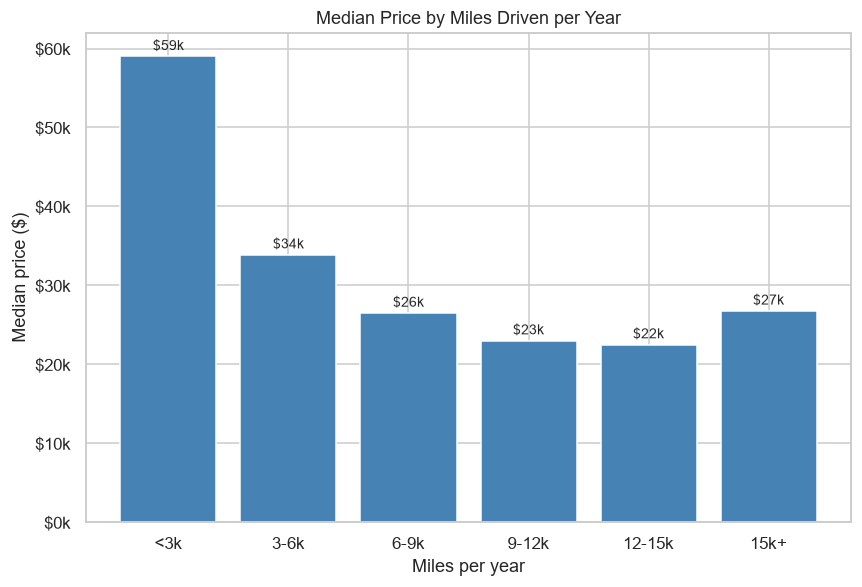

In [26]:
fig, ax = plt.subplots(figsize=(8, 5.5))
ax.bar(mpy_stats.index.astype(str), mpy_stats["median"], color="steelblue")
ax.set_title("Median Price by Miles Driven per Year")
ax.set_xlabel("Miles per year")
ax.set_ylabel("Median price ($)")
ax.yaxis.set_major_formatter(lambda v, _: f"${v/1000:.0f}k")
for i, v in enumerate(mpy_stats["median"]):
    ax.text(i, v + 800, f"${v/1000:.0f}k", ha="center", fontsize=9)
plt.tight_layout()
plt.savefig("../reports\\figures\\price_by_mileage_per_year.png")
plt.show()

## Step 7 : Bonus Mystery Question
Are the unrealistic mileage-per-year values real outliers, or cleaning mistakes?

In [23]:
cols = ["brand", "model", "model_year", "milage", "price", "mileage_per_year"]
print("Highest mileage_per_year")
print(df_clean.sort_values("mileage_per_year", ascending=False)[cols].head(6).to_string())
print()
print("Lowest mileage_per_year")
print(df_clean.sort_values("mileage_per_year")[cols].head(6).to_string())

Highest mileage_per_year
              brand                     model  model_year    milage    price  mileage_per_year
3348  Mercedes-Benz             Sprinter 2500        2016  399000.0  24500.0           44333.0
116             RAM  ProMaster 3500 High Roof        2021  147834.0  32662.0           36958.0
2764          Honda              Accord Sport        2013  405000.0   6000.0           33750.0
2232           Ford          Transit-350 Base        2018  235000.0  18000.0           33571.0
2926           Ford                 F-250 XLT        2017  244000.0  35500.0           30500.0
1281      Chevrolet        Silverado 3500 LTZ        2022   85200.0  67500.0           28400.0

Lowest mileage_per_year
              brand                    model  model_year  milage     price  mileage_per_year
3018            GMC          Sierra 1500 AT4        2022   100.0   62499.0              33.0
1848  Mercedes-Benz  Sprinter 3500 High Roof        2022   105.0  200000.0              35.0
487   

## Conclusion

In [24]:
lux_med = tier_stats.loc["Luxury", "median"]; eco_med = tier_stats.loc["Economy", "median"]
lux_mean = tier_stats.loc["Luxury", "mean"]; eco_mean = tier_stats.loc["Economy", "mean"]
print(f"Luxury vs Economy: median ${lux_med:,.0f} vs ${eco_med:,.0f} ({lux_med/eco_med:.1f}x), mean ${lux_mean:,.0f} vs ${eco_mean:,.0f} ({lux_mean/eco_mean:.1f}x)")
print(f"1-3 year cars median: ${df_clean.loc[df_clean['car_age']<=3,'price'].median():,.0f}")
print(f"16+ year cars median: ${df_clean.loc[df_clean['car_age']>=16,'price'].median():,.0f}")

Luxury vs Economy: median $39,998 vs $27,000 (1.5x), mean $61,823 vs $31,795 (1.9x)
1-3 year cars median: $56,820
16+ year cars median: $12,350


Vehicle age is the strongest pricing factor, while brand tier consistently shapes the price level. Cleaning and validating the data were equally important, ensuring reliable comparisons and preventing missing values and extreme outliers from distorting the results.

### Business Recommendations

1) Price around vehicle age. Model year should be the starting point, with mileage and vehicle tier used to refine the price.

2) Use 9,000 miles per year as a threshold. Low-use cars can command a premium, while price reductions should flatten beyond roughly 9,000 miles per year.

3) Balance luxury and economy inventory. Luxury cars offer higher value per vehicle, while economy cars provide greater listing volume.

4) Add a price validation check. Brand-level median checks can catch extreme entries, such as the $2.95M Maserati, before they distort the analysis.